In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive/anemia_detection/datasets')

['palpablepalm_dataset.zip',
 'fingernails_dataset.zip',
 'conjunctiva_dataset.zip']

In [ ]:
!unzip "/content/drive/MyDrive/anemia_detection/datasets/conjunctiva_dataset.zip"


Archive:  /content/drive/MyDrive/anemia_detection/datasets/conjunctiva_dataset.zip
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (6).png  
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (2).png  
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (3).png  
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (4).png  
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (5).png  
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (7).png  
  inflating: Application of Machine Learn

In [ ]:
import os

os.listdir('/content')
dataset_path = "/content/Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana"
from glob import glob

images = glob(dataset_path + "/*.png")

print("Toplam görüntü:", len(images))
print(images[:5])

Toplam görüntü: 4262
['/content/Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-044.png', '/content/Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-008 (9).png', '/content/Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-049 (4).png', '/content/Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-036 (6).png', '/content/Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Non-Anemic-030 (3).png']


In [ ]:
import os
from glob import glob

images = glob(dataset_path + "/*")

print("Toplam bulunan dosya:", len(images))
for x in images[:10]:
    print(repr(os.path.basename(x)))

Toplam bulunan dosya: 4262
'Anemic-044.png'
'Anemic-008 (9).png'
'Anemic-049 (4).png'
'Anemic-036 (6).png'
'Non-Anemic-030 (3).png'
'Anemic-023 (5).png'
'Non-anemic-Con-007 (7).png'
'Non-Anemic-051 (6).png'
'Anemic-014.png'
'Non-Anemic-174 (11).png'


In [ ]:
import os
import re
import pandas as pd
from glob import glob

files = glob(os.path.join(dataset_path, "*.png"))

def parse_filename(path):
    name = os.path.basename(path)
    stem = os.path.splitext(name)[0]

    # augmentation numarası
    aug_match = re.search(r"\((\d+)\)$", stem)
    if aug_match:
        aug_no = int(aug_match.group(1))
        stem_core = re.sub(r"\s*\(\d+\)$", "", stem)
    else:
        aug_no = 1
        stem_core = stem

    lower = stem_core.lower()

    # sınıf
    if lower.startswith("non-anemic"):
        cls = "Non-Anemic"
        rest = stem_core[len("Non-Anemic-"):] if stem_core.startswith("Non-Anemic-") else stem_core[len("Non-anemic-"):]
    elif lower.startswith("anemic"):
        cls = "Anemic"
        rest = stem_core[len("Anemic-"):]
    else:
        cls = "Unknown"
        rest = stem_core

    # subtype
    subtype = "base"
    if rest.endswith("FV"):
        subtype = "FV"
        rest = rest[:-2]
    elif rest.endswith("RA"):
        subtype = "RA"
        rest = rest[:-2]
    elif "Conj-" in rest:
        subtype = "Conj"
        rest = rest.replace("Conj-", "")
    elif "Con-" in rest:
        subtype = "Con"
        rest = rest.replace("Con-", "")

    # id yakala
    id_match = re.search(r"(\d+)", rest)
    sample_id = id_match.group(1) if id_match else None

    series_key = f"{cls}_{sample_id}_{subtype}"

    return {
        "filename": name,
        "class": cls,
        "sample_id": sample_id,
        "subtype": subtype,
        "aug_no": aug_no,
        "series_key": series_key,
        "path": path
    }

df = pd.DataFrame([parse_filename(f) for f in files])

print(df.head(20))
print("\nSubtype sayıları:")
print(df["subtype"].value_counts())

print("\nSeri sayıları:")
print(df["series_key"].nunique())

print("\nHer seride kaç görüntü var:")
print(df.groupby("series_key").size().value_counts().sort_index())

                      filename       class sample_id subtype  aug_no  \
0               Anemic-044.png      Anemic       044    base       1   
1           Anemic-008 (9).png      Anemic       008    base       9   
2           Anemic-049 (4).png      Anemic       049    base       4   
3           Anemic-036 (6).png      Anemic       036    base       6   
4       Non-Anemic-030 (3).png  Non-Anemic       030    base       3   
5           Anemic-023 (5).png      Anemic       023    base       5   
6   Non-anemic-Con-007 (7).png  Non-Anemic       007     Con       7   
7       Non-Anemic-051 (6).png  Non-Anemic       051    base       6   
8               Anemic-014.png      Anemic       014    base       1   
9      Non-Anemic-174 (11).png  Non-Anemic       174    base      11   
10          Anemic-216 (6).png      Anemic       216    base       6   
11          Anemic-064 (2).png      Anemic       064    base       2   
12     Non-Anemic-184 (11).png  Non-Anemic       184    base    

In [ ]:
anemic_count = df["filename"].str.startswith("Anemic").sum()
non_anemic_count = (
    df["filename"].str.startswith("Non-Anemic").sum()
    + df["filename"].str.startswith("Non-anemic").sum()
)

print("Anemic ile başlayan:", anemic_count)
print("Non-anemic ile başlayan:", non_anemic_count)
print("Toplam:", anemic_count + non_anemic_count)

Anemic ile başlayan: 2558
Non-anemic ile başlayan: 1704
Toplam: 4262


In [ ]:
import cv2
import numpy as np

# Tüm veriyi kullan
df_exp = df.copy()

print("Kullanılan veri sayısı:", len(df_exp))
print(df_exp["subtype"].value_counts())
print(df_exp["class"].value_counts())

features = []
labels = []

for _, row in df_exp.iterrows():
    img = cv2.imread(row["path"])
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    L, a, b = cv2.split(lab)

    mean_a = np.mean(a)
    mean_b = np.mean(b)
    mean_g = np.mean(img[:, :, 1])

    features.append([mean_a, mean_b, mean_g])

    if row["class"] == "Anemic":
        labels.append(1)
    else:
        labels.append(0)

X = np.array(features, dtype=np.float32)
y = np.array(labels, dtype=np.int32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sınıf dağılımı:", np.bincount(y))
print("İlk 5 feature:\n", X[:10])
print("İlk 5 label:\n", y[:10])

Kullanılan veri sayısı: 4262
subtype
base    3808
Con      224
Conj     206
FV        12
RA        12
Name: count, dtype: int64
class
Anemic        2558
Non-Anemic    1704
Name: count, dtype: int64
X shape: (4262, 3)
y shape: (4262,)
Sınıf dağılımı: [1704 2558]
İlk 5 feature:
 [[130.36568  130.04454   37.641766]
 [135.11038  131.48012   21.319073]
 [135.2309   133.4867    33.809765]
 [131.80214  129.57295   43.12559 ]
 [134.05496  130.84024   14.753381]
 [135.77184  137.26173   28.36595 ]
 [138.39784  137.25983   22.909847]
 [135.0069   133.2806    45.2016  ]
 [132.73578  131.16858   24.129963]
 [132.86534  132.25502   65.1315  ]]
İlk 5 label:
 [1 1 1 1 0 1 0 0 1 0]


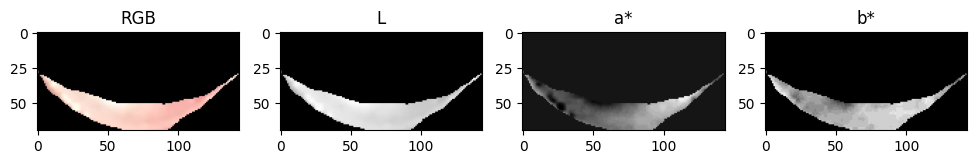

In [ ]:
import matplotlib.pyplot as plt

row = df_exp.iloc[0]

img = cv2.imread(row["path"])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

L,a,b = cv2.split(lab)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("RGB")

plt.subplot(1,4,2)
plt.imshow(L,cmap="gray")
plt.title("L")

plt.subplot(1,4,3)
plt.imshow(a,cmap="gray")
plt.title("a*")

plt.subplot(1,4,4)
plt.imshow(b,cmap="gray")
plt.title("b*")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Önce test %20 ayır
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Kalan %80 içinden validation %10 olacak şekilde ayır
# %10 / %80 = 0.125
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (2982, 3) (2982,)
Val  : (427, 3) (427,)
Test : (853, 3) (853,)


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(
    kernel="rbf",
    C=250,
    gamma="auto",
    probability=True,
    random_state=42
),
    "k-NN": KNeighborsClassifier(n_neighbors=1),
    "Decision Tree": DecisionTreeClassifier(
    criterion='gini',       # veya 'entropy' – bilgi kazancına göre bölme
    max_depth=25,         # Ağacın maksimum derinliği, overfitting’i engellemek için sınır koyabilirsin
    min_samples_split=2,    # Dallanmak için gereken minimum örnek sayısı
    min_samples_leaf=2,     # Yaprakta bulunacak minimum örnek sayısı
    max_features='log2',      # Bölmede kullanılacak maksimum özellik sayısı
    random_state=42
),
    "Gradient Boosting": GradientBoostingClassifier(
    n_estimators=500,        # Kaç ağaç kullanılacağı, default 100. Daha fazla → genellikle daha iyi performans
    learning_rate=0.5,      # Her ağacın katkısı, default 0.1. Küçük değer → daha stabil öğrenme
    max_depth=3,             # Ağaç derinliği, default 3. Daha derin → overfitting riski
    min_samples_split=2,     # Dallanma için minimum örnek sayısı
    min_samples_leaf=1,      # Yaprak başına minimum örnek sayısı
    subsample=0.8,           # Rastgele alt örnekleme oranı, 0.8 → overfitting azaltır
    max_features=None,       # Her ağacı oluştururken kullanılacak özellik sayısı
    random_state=42
),

  "XGBoost": XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    min_child_weight=1,
    gamma=0,
    subsample=1,
    colsample_bytree=0.95,
    reg_alpha=0,
    reg_lambda=1,
    eval_metric="logloss",
    random_state=42
),

  "CatBoost": CatBoostClassifier(
    iterations=1000,           # Kaç ağaç oluşturulacağı, default 100
    learning_rate=0.5,        # Öğrenme hızı, küçük değer → daha stabil sonuç
    depth=6,                   # Ağaç derinliği, default 6
    l2_leaf_reg=3,             # L2 regularization katsayısı
    subsample=0.8,             # Rastgele örnekleme oranı
    colsample_bylevel=0.8,     # Özellik örnekleme oranı
    verbose=0,
    random_state=42
),

  "AdaBoost": AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, min_samples_leaf=2),      # Temel öğrenici, default DecisionTreeClassifier(max_depth=1)
    n_estimators=1000,          # Kaç ağaç/estimator oluşturulacağı, default 50
    learning_rate=1,        # Her estimator’un katkı ağırlığı, default 1.0
    random_state=42
),

    "HistGradientBoosting": HistGradientBoostingClassifier(
    max_iter=100,            # Kaç boosting iterasyonu yapılacağı, default 100
    learning_rate=0.5,       # Öğrenme hızı
    max_depth=None,           # Her ağaç için maksimum derinlik, None → tam büyüme
    min_samples_leaf=20,      # Yaprak başına minimum örnek sayısı
    max_leaf_nodes=31,        # Her ağacın maksimum yaprak sayısı
    l2_regularization=0.0,    # L2 regularizasyon katsayısı
    random_state=42
)
}
cv = KFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    print(f"\n{name}")
    print("10-fold CV mean accuracy:", scores.mean())
    print("10-fold CV std:", scores.std())


Naive Bayes
10-fold CV mean accuracy: 0.6096653273776121
10-fold CV std: 0.03181493161601538

SVM
10-fold CV mean accuracy: 0.9963109694507419
10-fold CV std: 0.003503676424919086

k-NN
10-fold CV mean accuracy: 0.9979865771812081
10-fold CV std: 0.0016439528475055134

Decision Tree
10-fold CV mean accuracy: 0.9875883818545038
10-fold CV std: 0.004762920918569286

Gradient Boosting
10-fold CV mean accuracy: 0.9969798657718121
10-fold CV std: 0.0027874576721201734

XGBoost
10-fold CV mean accuracy: 0.9969798657718121
10-fold CV std: 0.0038113478830874487

CatBoost
10-fold CV mean accuracy: 0.9969798657718121
10-fold CV std: 0.0023489932885906047

AdaBoost
10-fold CV mean accuracy: 0.9966442953020135
10-fold CV std: 0.003675990318826633

HistGradientBoosting
10-fold CV mean accuracy: 0.9966454176112769
10-fold CV std: 0.0036759918607513105


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # bazı modellerde predict_proba olmayabilir
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = roc_auc_score(y_test, y_pred)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Algorithm": name,
        "Accuracy": round(acc*100,4),
        "F1-score": round(f1*100,4),
        "AUC": round(auc*100,4),
        "Precision": round(prec*100,4),
        "Recall": round(rec*100,4)
    })

results_df = pd.DataFrame(results)

results_df

,Algorithm,Accuracy,F1-score,AUC,Precision,Recall
0,Naive Bayes,60.2579,72.1903,61.3745,62.2348,85.9375
1,SVM,99.8828,99.9024,99.8024,99.8051,100.0000
2,k-NN,99.7655,99.8043,99.8047,100.0000,99.6094
3,Decision Tree,99.4138,99.5131,99.7543,99.2233,99.8047
4,Gradient Boosting,100.0000,100.0000,100.0000,100.0000,100.0000
5,XGBoost,99.8828,99.9022,99.9977,100.0000,99.8047
6,CatBoost,99.8828,99.9022,99.9994,100.0000,99.8047
7,AdaBoost,99.8828,99.9022,99.9914,100.0000,99.8047
8,HistGradientBoosting,99.8828,99.9024,100.0000,99.8051,100.0000


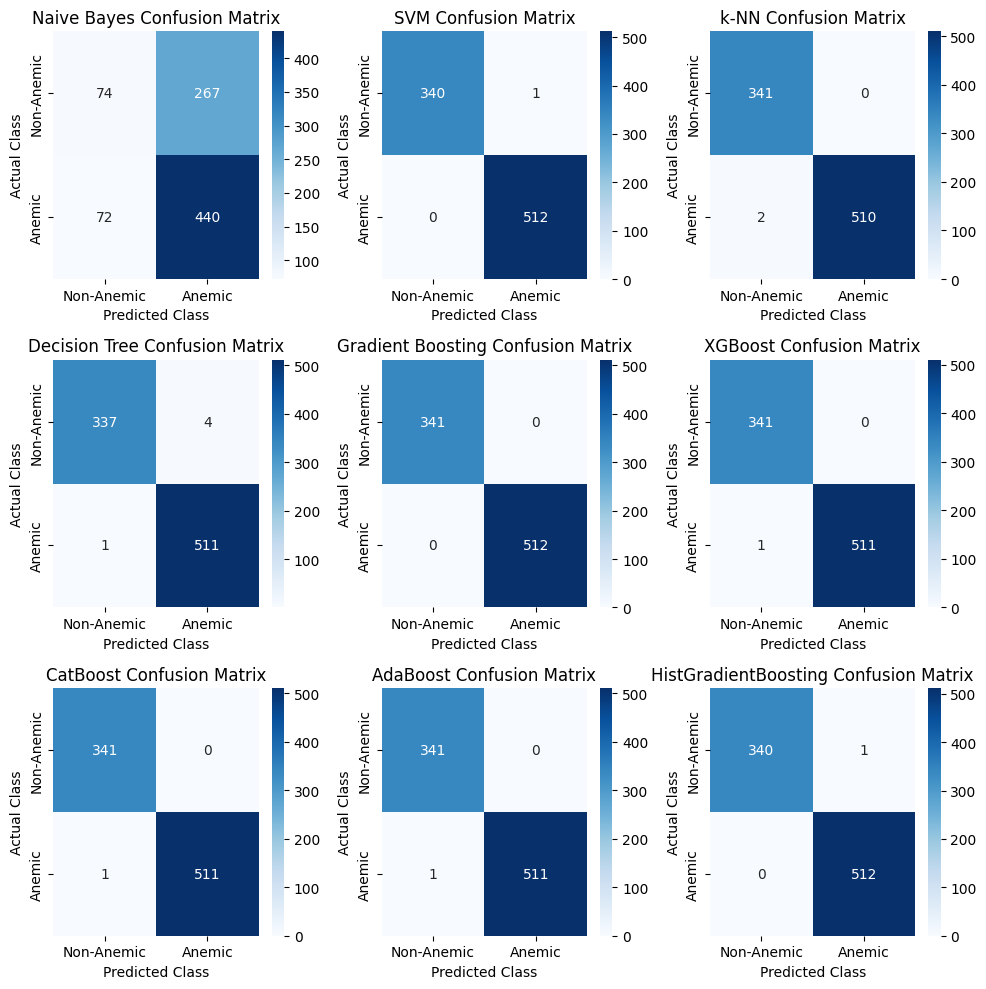

In [ ]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3,3, figsize=(10,10))

axes = axes.flatten()

for i, (name,model) in enumerate(models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test,y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        xticklabels=["Non-Anemic","Anemic"],
        yticklabels=["Non-Anemic","Anemic"]
    )

    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xlabel("Predicted Class")
    axes[i].set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

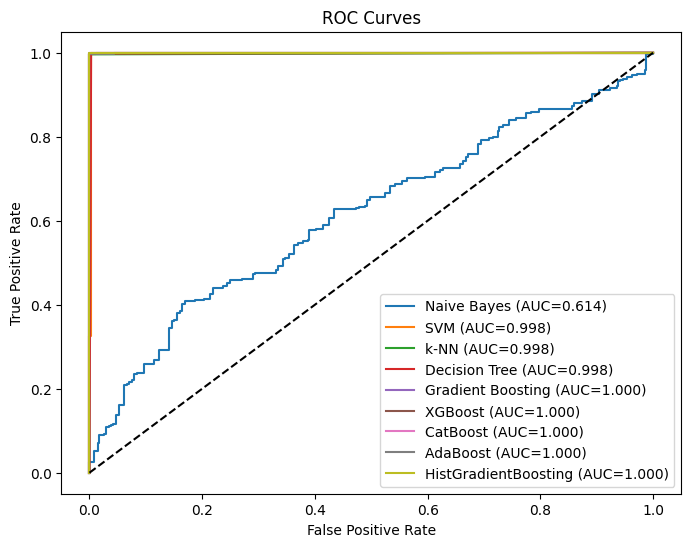

In [ ]:

from sklearn.metrics import roc_curve, auc as sk_auc

plt.figure(figsize=(8,6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
    else:
        probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = sk_auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [ ]:
import joblib
import os

# Kaydedilecek klasör
model_folder = "conjunctiva_models"
os.makedirs(model_folder, exist_ok=True)

for name, model in models.items():
    # Modeli dosyaya kaydet
    filename = os.path.join(model_folder, f"{name.replace(' ','_')}.joblib")
    joblib.dump(model, filename)
    print(f"{name} kaydedildi → {filename}")

Naive Bayes kaydedildi → conjunctiva_models/Naive_Bayes.joblib
SVM kaydedildi → conjunctiva_models/SVM.joblib
k-NN kaydedildi → conjunctiva_models/k-NN.joblib
Decision Tree kaydedildi → conjunctiva_models/Decision_Tree.joblib
Gradient Boosting kaydedildi → conjunctiva_models/Gradient_Boosting.joblib
XGBoost kaydedildi → conjunctiva_models/XGBoost.joblib
CatBoost kaydedildi → conjunctiva_models/CatBoost.joblib
AdaBoost kaydedildi → conjunctiva_models/AdaBoost.joblib
HistGradientBoosting kaydedildi → conjunctiva_models/HistGradientBoosting.joblib



LightGBM
10-fold CV mean accuracy: 0.9969809880810756
10-fold CV std: 0.002787324592215752
  Algorithm  Accuracy  F1-score    AUC  Precision   Recall
0  LightGBM   99.8828   99.9022  100.0      100.0  99.8047


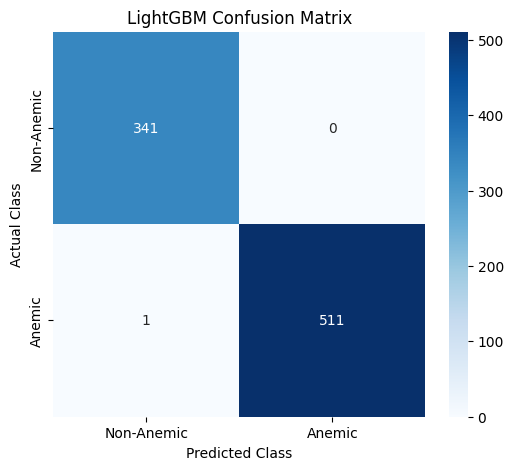

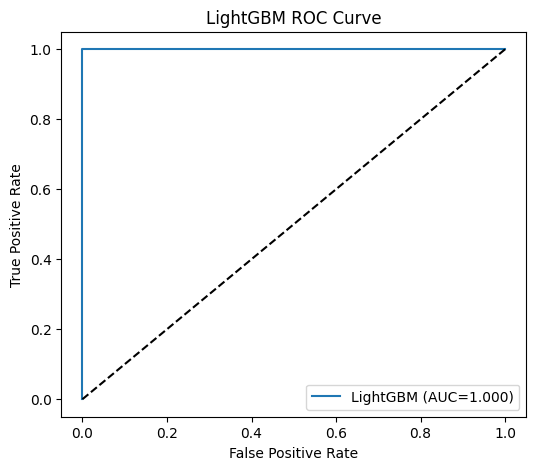

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc as sk_auc
import matplotlib.pyplot as plt
import seaborn as sns

# LightGBM için veri
X_train_lgb = pd.DataFrame(X_train, columns=["mean_a","mean_b","mean_g"])
X_test_lgb  = pd.DataFrame(X_test,  columns=["mean_a","mean_b","mean_g"])

# LightGBM modeli
lgb_model = LGBMClassifier(
    n_estimators=1000,        # Kaç ağaç oluşturulacağı, default 100
    learning_rate=0.05,       # Öğrenme hızı, küçük değer → daha stabil sonuç
    max_depth=-1,             # Maksimum ağaç derinliği, -1 → sınırsız
    num_leaves=31,            # Her ağaçta maksimum yaprak sayısı
    min_child_samples=20,     # Yaprak başına minimum örnek sayısı
    subsample=0.8,            # Rastgele örnekleme oranı
    colsample_bytree=0.8,     # Özellik örnekleme oranı
    reg_alpha=0.0,            # L1 regularizasyon
    reg_lambda=0.0,           # L2 regularizasyon
    random_state=42,
    verbose=-1
)

# 10-fold cross validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(lgb_model, X_train_lgb, y_train, cv=cv, scoring="accuracy")
print("\nLightGBM")
print("10-fold CV mean accuracy:", scores.mean())
print("10-fold CV std:", scores.std())

# Modeli train et ve test et
lgb_model.fit(X_train_lgb, y_train)
y_pred = lgb_model.predict(X_test_lgb)

# predict_proba kullanarak AUC hesapla
y_prob = lgb_model.predict_proba(X_test_lgb)[:,1]
auc = roc_auc_score(y_test, y_prob)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Sonuçları dataframe’e ekle
results_lgb = pd.DataFrame([{
    "Algorithm": "LightGBM",
    "Accuracy": round(acc*100,4),
    "F1-score": round(f1*100,4),
    "AUC": round(auc*100,4),
    "Precision": round(prec*100,4),
    "Recall": round(rec*100,4)
}])

print(results_lgb)

# LightGBM için prediction
y_pred_lgb = lgb_model.predict(X_test_lgb)
y_prob_lgb = lgb_model.predict_proba(X_test_lgb)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lgb)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Anemic","Anemic"],
    yticklabels=["Non-Anemic","Anemic"]
)
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lgb)
roc_auc = sk_auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"LightGBM (AUC={roc_auc:.3f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM ROC Curve")
plt.legend()
plt.show()

In [ ]:
import joblib
import os

# Kaydedilecek klasör
model_folder = "conjunctiva_models"

# LightGBM modelini kaydet
filename = os.path.join(model_folder, "LightGBM_model.joblib")
joblib.dump(lgb_model, filename)
print(f"LightGBM modeli kaydedildi → {filename}")

LightGBM modeli kaydedildi → conjunctiva_models/LightGBM_model.joblib
